# Single GPU Optimization

In this notebook, you will gain some hands-on experience with improving single-GPU training speed and scaling training to multiple GPUs.

**What we will do:**
- Implement benchmarking and profiling harness.
- Implement Flash Attention 2 Triton kernel.

We will look into how to optimize the performance of our transformer model to make the most efficient use of the GPU. We will profile our model to understand where it spends time and memory during the forward and backward passes, then optimize the self-attention operation with custom GPU kernels, making it faster than a straightforward PyTorch implementation. In the subsequent parts of the notebook we will leverage multiple GPUs.

In [ ]:
import math
import numpy as np
import torch
import torch.nn as nn
from einops import rearrange, einsum

import sys; sys.path.insert(0, '..')
from tests.test_single_gpu_optimization import *

In [ ]:
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

In [ ]:
def get_device():
    if torch.cuda.is_available():
        return 'cuda'
    if torch.backends.mps.is_available():
        return 'mps'
    return 'cpu'

device = get_device()
print(f'device = {device}')

## Profiling and Benchmarking

Before implementing any optimization, it is helpful to first profile our program to understand where it spends resources (e.g. time and memory). Otherwise, we risk optimizing parts of the model that don’t account for significant time or memory, and therefore not seeing measurable end-to-end improvements.

We will implement three performance evaluation paths: 
1. A simple, end-to-end benchmarking using the Python standard library to time our forward and backward passes.
2. Profile compute with the NVIDIA Nsight Systems tool to understand how that time is distributed across operations on both the CPU and GPU.
3. Profile memory usage.

### Setup - Importing your transformer model

To start, we'll need to import all the model classes, functions, and saved model files we created in previous notebooks. I may put these in a script at some point so this is automatic, but for now you can just copy and paste the code into the cell below and also import any model files as needed.

In [ ]:
# insert code / load files

### Model Sizing

Throughout this notebook, we will be benchmarking and profiling models to better understand their performance. To get a sense of how things change at scale, we will work with and refer to the following model configurations. For all models, we’ll use a vocabulary size of 10,000 and a batch size of 4, with varying context lengths. This notebook and later ones may require a lot of results to be presented in tables. To make that easy, we recommend that you automate constructing tables for your writeup in code, since formatting tables can be very tedious. See `pandas.DataFrame.to_latex()` and `pandas.DataFrame.to_markdown()` or write your own function to generate them from your preferred tabular representation.

<center>
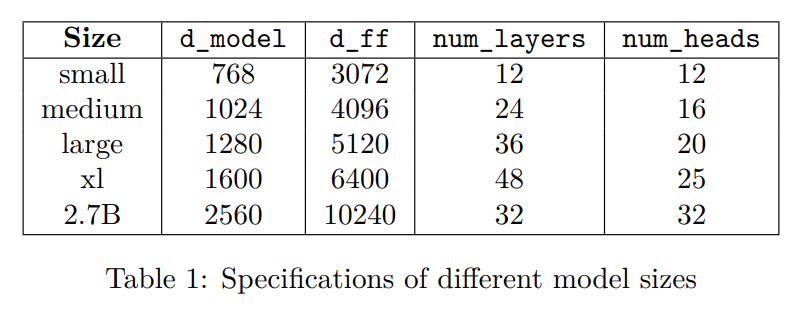
</center>


### End-to-End Benchmarking

We will now implement a simple performance evaluation script. We will be testing many variations of our model (changing precision, swapping layers, etc.), so *it will pay off to have your script enable these variations via command-line arguments* to make them easy to run later on. We also recommend running sweeps over benchmarking hyperparameters, such as model size, context length, etc., using `sbatch` or `submitit` on Slurm for quick iteration.

To start off, let’s do the simplest possible profiling of our model by timing the forward and backward passes. Since we will only be measuring speed and memory, we will use random weights and data.

Measuring performance is subtle — some common traps can cause us to not measure what we want. For benchmarking GPU code, one caveat is that CUDA calls are *asynchronous*. When you call a CUDA kernel, such as when you invoke `torch.matmul`, the function call returns control to your code without waiting for the matrix multiplication to finish. In this way, the CPU can continue running while the GPU computes the matrix multiplication. On the other hand, this means that naively measuring how long the `torch.matmul` call takes to return does not tell us how long the GPU takes to actually run the matrix multiplication In PyTorch, we can call `torch.cuda.synchronize()` to wait for all GPU kernels to complete, allowing us to get more accurate measurements of CUDA kernel runtime. With this in mind, let’s write our basic profiling infrastructure.

#### Problem: Benchmarking Script

1. Write a script to perform basic end-to-end benchmarking of the forward and backward passes in your model. Create a script that will initialize a `basics` transformer model with the given hyperparameters, create a random batch of data, and time forward and backward passes. Specifically, your script should support the following:
    - Given hyperparameters (e.g. number of layers), initialize a model.
    - Generate a random batch of data.
    - Run $w$ warm-up steps (before you start measuring time), then time the execution of $n$ steps (either only forward, or both forward and backward passes, depending on an argument). For timing, you can use the Python `timeit` module (e.g. either using the timeit function, or using `timeit.default_timer()`, which gives you the system’s highest resolution clock, thus a better default for benchmarking than `time.time()`).
    - Call `torch.cuda.synchronize()` after each step.
2.  Time the forward and backward passes for the model sizes described in above. Use 5 warmup steps and compute the average and standard deviation of timings over 10 measurement steps. How long does a forward pass take? How about a backward pass? Do you see high variability across measurements, or is the standard deviation small?
3.  One caveat of benchmarking is not performing the warm-up steps. Repeat your analysis without the warm-up steps. How does this affect your results? Why do you think this happens? Also try to run the script with 1 or 2 warm-up steps. Why might the result still be different?

In [ ]:
# implement code / run script

### Nsight Systems Profiler

End-to-end benchmarking does not tell us where our model spends time and memory during forward and backward passes, and so does not expose specific optimization opportunities. To know how much time our program spends in each component (e.g. function), we can use a profiler. An execution profiler instruments the code by inserting guards when functions begin and finish running, and thus can give detailed execution statistics at the function level (such as number of calls, how long they take on average, cumulative time spent on this function, etc).

Standard Python profilers, e.g. `CProfile`, are not able to profile CUDA kernels since these kernels are executed asynchronously on the GPU. Fortunately, NVIDIA ships a profiler that we can use via the CLI `nsys`, which we have already installed for you. In this part of the notebook, we'll will use `nsys` to analyze the runtime of your transformer model. Using nsys is straightforward: we can simply run your Python script from the previous section with `nsys profile` prepended. For example, you can profile a script `benchmark.py` and write the output to a file `result.nsys.rep` with:

```bash
~$ nsys profile -o result python benchmark.py
```

You can then view the profile on your local machine with the NVIDIA Nsight Systems desktop application. Selecting a particular `CUDA API` call (on the CPU) in the CUDA API row of the profile will highlight all corresponding kernel executions (on the GPU) in the `CUDA HW` row.

We encourage you to experiment with various command-line options for nsys profile to get a sense of what it can do. Notably, you can get Python backtraces for each CUDA API call with `--python-backtrace=cuda`, though this may introduce overhead. You can also annotate your code with NVTX ranges, which will appear as blocks in the `NVTX` row of the profile capturing all CUDA API calls and associated kernel executions. In particular, you should use NVTX ranges to *ignore the warm-up steps in your benchmarking script* (by applying a filter on the `NVTX` row in the profile). You can also isolate which kernels are responsible for the forward and backward passes of your model, and you can even isolate which kernels are responsible for different parts of a self-attention layer by annotating your implementation as follows:

```python
...
import torch.cuda.nvtx as nvtx

@nvtx.range('scaled dot product attention')
def annotated_scaled_dot_product_attention(..., Q, K, V, mask):
    ...
    with nvtx.range('computing attention scores'):
    ... # compute attention scores between Q and K
    with nvtx.range('computing softmax')
    ... # compute softmax of attention scores
    with nvtx.range('final matmul')
    ... # compute output projection
    return ...
```

You can swap your original implementation with the annotated version in your benchmarking script via:

```python
cs336_basics.model.scaled_dot_product_attention = annotated_scaled_dot_product_attention
```

Finally, you can use the `--pytorch` command-line option with `nsys` to automatically annotate calls to the PyTorch C++ API with NVTX ranges.

#### Problem: NSYS Profile

Profile your forward pass, backward pass, and optimizer step using nsys with each of the model sizes described in *Table 1* and context lengths of 128, 256, 512 and 1024. You may run out of memory with some of these context lengths for the larger models, in which case just note it in your report.
1. What is the total time spent on your forward pass? Does it match what we had measured before with the Python standard library?
2. What CUDA kernel takes the most cumulative GPU time during the forward pass? How many times is this kernel invoked during a single forward pass of your model? Is it the same kernel that takes the most runtime when you do both forward and backward passes? (Hint: look at the "CUDA GPU Kernel Summary" under "Stats Systems View", and filter using NVTX ranges to identify which parts of the model are responsible for which kernels.)
3. Although the vast majority of FLOPs take place in matrix multiplications, you will notice that several other kernels still take a non-trivial amount of the overall runtime. What other kernels besides matrix multiplies do you see accounting for non-trivial CUDA runtime in the forward pass?
4. Profile running one complete training step with your implementation of AdamW (i.e. the forward pass, computing the loss and running a backward pass, and finally an optimizer step, as you’d do during training). How does the fraction of time spent on matrix multiplication change, compared to doing inference (forward pass only)? How about other kernels?
5. Compare the runtime of the softmax operation versus the matrix multiplication operations within the self-attention layer of your model during a forward pass. How does the difference in runtimes compare to the difference in FLOPs?

In [ ]:
# implement code / run script

### Mixed Precision

Up to this point, we’ve been running with FP32 precision. All model parameters and activations have the `torch.float32` datatype. However, modern NVIDIA GPUs contain specialized GPU cores (Tensor Cores) for accelerating matrix multiplies at lower precisions. For example, the NVIDIA A100 spec sheet says that its maximum throughput with FP32 is 19.5 TFLOP/second, while its maximum throughput with FP16 (half-precision floats) or BF16 (brain floats) is significantly higher at 312 TFLOP/second. As a result, using lower-precision datatypes should help us speed up training and inference.

However, naively casting our model into a lower-precision format may come with reduced model accuracy. For example, many gradient values in practice are often too small to be representable in FP16, and thus become zero when naively training with FP16 precision. To combat this, it’s common to use loss scaling when training with FP16—the loss is simply multiplied by a scaling factor, increasing gradient magnitudes so they don’t flush to zero. Furthermore, FP16 has a lower dynamic range than FP32, which can lead to overflows that manifest as a NaN loss. Full `bfloat16` training is generally more stable (since BF16 has the same dynamic range as FP32), but can still affect final model performance compared to FP32.

To take advantage of the speedups from lower-precision datatypes, it’s common to use mixed-precision training. In PyTorch, this is implemented with the `torch.autocast` context manager. In this case, certain operations (e.g. matrix multiplies) are performed in lower-precision datatypes, while other operations that require the full dynamic range of FP32 (e.g. accumulations and reductions) are kept as-is. For example, the following code will automatically identify which operations to perform in lower-precision during the forward pass and cast these operations to the specified data type:

```python
model : torch.nn.Module = ... # e.g. your transformer model
dtype : torch.dtype = ... # e.g. torch.float16
x : torch.Tensor = ... # input data

with torch.autocast(device='cuda', dtype=dtype):
y = model(x)
```

As alluded to above, it is generally a good idea to keep accumulations in higher precision even if the tensors themselves being accumulated have been downcasted. The following exercise will help build your intuition as to why this is the case.

#### Problem: Mixed Precision Accumulation

Run the following code and commment on the (accuracy of the) results with a 2-3 sentence response.

```python
s = torch.tensor(0,dtype=torch.float32)
for i in range(1000):
s += torch.tensor(0.01,dtype=torch.float32)
print(s)
s = torch.tensor(0,dtype=torch.float16)
for i in range(1000):
s += torch.tensor(0.01,dtype=torch.float16)
print(s)
s = torch.tensor(0,dtype=torch.float32)
for i in range(1000):
s += torch.tensor(0.01,dtype=torch.float16)
print(s)
s = torch.tensor(0,dtype=torch.float32)
for i in range(1000):
x = torch.tensor(0.01,dtype=torch.float16)
s += x.type(torch.float32)
print(s)
```

In [ ]:
# implement code

#### Problem: Benchmarking Mixed Precision

We will now apply mixed precision first to a toy model for intuition and then to our benchmarking script.

1. Consider the toy model given in the code block below. Suppose we are training the model on a GPU and that the model parameters are originally in FP32. We’d like to use autocasting mixed precision with FP16. What are the data types of:
    - the model parameters within the autocast context,
    - the output of the first feed-forward layer (`ToyModel.fc1`),
    - the output of layer norm (`ToyModel.ln`),
    - the model’s predicted logits,
    - the loss,
    - and the model’s gradients?

```python
class ToyModel(nn.Module):
    def __init__(self, in_features: int, out_features: int):
        super().__init__()
        self.fc1 = nn.Linear(in_features, 10, bias=False)
        self.ln = nn.LayerNorm(10)
        self.fc2 = nn.Linear(10, out_features, bias=False)
        self.relu = nn.ReLU()
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.ln(x)
        x = self.fc2(x)
        return x
```

2. You should have seen that FP16 mixed precision autocasting treats the layer normalization layer differently than the feed-forward layers. What parts of layer normalization are sensitive to mixed precision? If we use BF16 instead of FP16, do we still need to treat layer normalization differently? Why or why not?

3. Modify your benchmarking script to optionally run the model using mixed precision with BF16. Time the forward and backward passes with and without mixed-precision for each language model size described in the *Table 1* above. Compare the results of using full vs. mixed precision, and comment on any trends as model size changes. You may find the nullcontext no-op context manager to be useful. Give a 2-3 sentence response with your timings and commentary.

In [ ]:
# implement code / run script

### Profiling Memory

So far, we have been looking at compute performance. We’ll now shift our attention to *memory*, another major resource in language model training and inference. PyTorch also ships with a powerful memory profiler, which can keep track of allocations over time.

To use the memory profiler, you can modify your benchmarking script as follows:

```python
... # warm-up phase in your benchmarking script
# Start recording memory history.
torch.cuda.memory._record_memory_history(max_entries=1000000)
# what you want to profile in your benchmarking script
# Save a pickle file to be loaded by PyTorch online tool.
torch.cuda.memory._dump_snapshot('memory_snapshot.pickle')
# Stop recording history.
torch.cuda.memory._record_memory_history(enabled=None)
```
This will output a file `memory_snapshot.pickle` that you can load into the PyTorch online [memory viz tool](https://pytorch.org/memory_viz). This tool will let you see the overall memory usage timeline as well as each individual allocation that was made, with its size and a stack trace leading to the code where it originates. To use this tool, you should open the link above in a Web browser, and then drag and drop your Pickle file onto the page.

#### Problem: Memory Profiling

You will now use the PyTorch profiler to analyze the memory usage of your model. Profile your forward pass, backward pass, and optimizer step of the 2.7B model from *Table 1* above with context lengths of 128, 256 and 512.

1. Add an option to your profiling script to run your model through the memory profiler. It may be helpful to reuse some of your previous infrastructure (e.g. to activate mixed-precision, load specific model sizes, etc). Then, run your script to get a memory profile of the 2.7B model when either doing inference only (just forward pass) or a full training step. How do your memory timelines look like? Can you tell which stage is running based on the peaks you see? Create two images of the "Active memory timeline" of a 2.7B model, from the `memory_viz` tool: one for the forward pass, and one for running a full training step (forward and backward passes, then optimizer step), and a 2-3 sentence response.
2. What is the peak memory usage of each context length when doing a forward pass? What about when doing a full training step? Provide a table with two numbers per context length.
3. Find the peak memory usage of the 2.7B model when using mixed-precision, for both a forward pass and a full optimizer step. Does mixed-precision significantly affect memory usage?
4. Consider the 2.7B model. At our reference hyperparameters, what is the size of a tensor of activations in the transformer residual stream, in single-precision? Give this size in MB (i.e. divide the number of bytes by $1024^2$). Provide a 1-2 sentence response with your derivation.
5. Now look closely at the “Active Memory Timeline” from the PyTorch online `memory_viz` tool of a memory snapshot of the 2.7B model doing a forward pass. When you reduce the "Detail" level, the tool hides the smallest allocations to the corresponding level (e.g. putting "Detail" at 10% only shows the 10% largest allocations). What is the size of the largest allocations shown? Looking through the stack trace, can you tell where those allocations come from?

In [ ]:
# implement code / run script

## Optimizing Attention with FlashAttention-2

### Benchmarking PyTorch Attention

Your profiling likely suggests that there is an opportunity for optimization, both in terms of memory and compute, in your attention layers. At a high level, the attention operation consists of a matrix multiplication followed by softmax, then another matrix multiplication:

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\text{mask}\left(\frac{Q^T K}{\sqrt{d_k}}\right)\right) V \ .
$$

The naive attention implementation needs to save attention score matrices of shape `seq_len × seq_len` for each batch/head element, which can grow very large with long sequence lengths, causing out-of-memory errors for any tasks with long inputs or outputs. We will implement an attention kernel following the FlashAttention2 paper, which computes attention by tiles and avoids ever explicitly materializing the `seq_len × seq_len` attention score matrices, enabling scaling to much longer sequence lengths.

#### Problem: PyTorch Attention

Benchmark your attention implementation at different scales. Write a script that will:
1. Fix the batch size to 8 and don’t use multihead attention (i.e. remove the head dimension).
2. Iterate through the cartesian product of `[16, 32, 64, 128]` for the head embedding dimension $d_{model}$, and `[256, 1024, 4096, 8192, 16384]` for the sequence length.
3. Create random inputs $Q$, $K$, $V$ for the appropriate size.
4. Time 100 forward passes through attention using the inputs.
5. Measure how much memory is in use before the backward pass starts, and time 100 backward passes.
6. Make sure to warm up, and to call `torch.cuda.synchronize()` after each forward/backward pass.

Report the timings (or out-of-memory errors) you get for these configurations. Try to answer the following:
- At what size do you get out-of-memory errors?
- Do the accounting for the memory usage of attention in one of the smallest configurations you find that runs out of memory (you can use the equations for memory usage of transformers from previous notebooks).
- How does the memory saved for backward change with the sequence length?
- What would you do to eliminate this memory cost?

It may be helpful to create a table with your timings and some calculations for working out the memory usage.

In [ ]:
# implement code / run script

## Benchmarking JIT-Compiled Attention

Since version 2.0, PyTorch also ships with a powerful just-in-time compiler that automatically tries to apply a number of optimizations to PyTorch functions: see [this link](https://pytorch.org/tutorials/intermediate/torch_compile_tutorial.html) for an intro. In particular, it will try to automatically generate fused Triton kernels by dynamically analyzing your computation graph. The interface to use the PyTorch compiler is very simple. For instance, if we wanted to apply it to a single layer of our model, we can use:

```python
layer = SomePyTorchModule(...)
compiled_layer = torch.compile(layer)
```

Now, `compiled_layer` functionally behaves just like `layer` (e.g. with its forward and backward passes). We can also compile our entire PyTorch model with `torch.compile(model)`, or even a Python function that calls PyTorch operations.

### Problem: Torch Compile

1. Extend your attention benchmarking script to include a compiled version of your PyTorch implementation of attention, and compare its performance to the uncompiled version with the same configuration as the pytorch_attention problem above. Provide a table comparing your forward and backward pass timings for your compiled attention module with the uncompiled version from the pytorch_attention problem above.
2. Now, compile your entire transformer model in your end-to-end benchmarking script. How doesthe performance of the forward pass change? What about the combined forward and backward passes and optimizer steps? Provide a table comparing your vanilla and compiled transformer model.

In [ ]:
# implement code / run script

Given the scaling behaviors we've seen with respect to the sequence length, we need significant improvements to handle large sequences. Even with `torch.compile` the current implementation suffers from very poor memory access patterns at long sequence length. For that, we will write a Triton implementation of FlashAttention-2, where we’ll have significantly more control over how memory is accessed and when to compute what.

#### Example: Weighted Sum

To introduce what you’ll need to know about Triton and how it interoperates with PyTorch, we will work through an example kernel for a "weighted sum" operation. For further resources on getting up to speed with Triton, see Triton’s tutorials. We note that these tutorials do not use the new, convenient block pointer abstraction, which we will walk through below.

Given an input matrix $X$, we’ll multiply its entries by a column-wise weight vector $w$, and sum each row, giving us the matrix-vector product of $X$ and $w$. We are going to work through the forward pass of this operation first, and then write the Triton kernel for the backward pass.

**Forward pass:** The forward pass of our kernel is just the following broadcasted inner product.

```python
def weighted_sum(x, weight):
    # Here, assume that x has n-dim shape [..., D], and weight has 1D shape [D]
    return (weight * x).sum(axis=-1)
```

When writing our Triton kernel, we’ll have each program instance (potentially running in parallel) compute the weighted sum of a *tile* of rows of $x$, and write the corresponding scalar outputs to the output tensor. In Triton, a program instance is a block of threads all running the same program, and these *thread blocks* can be run in parallel on the GPU. Instead of taking *tensors* as arguments, we take *pointers* to their first elements, as well as strides for each tensor that tell us how to move along axes.

We can use the strides to load a tensor corresponding to the tile of rows of $x$ that we’re summing in the running instance, using the program ID to divide up the work (i.e. instance $i$ will process the $i$-th tile of rows of $x$). The main difference between the forward pass in Triton and PyTorch in this simple case is the need to do pointer arithmetic and explicit loads/stores. We will use the block pointer abstraction with `tl.make_block_ptr` to greatly simplify the pointer arithmetic, although this means we need to do some setup to prepare the block pointers.

<center>
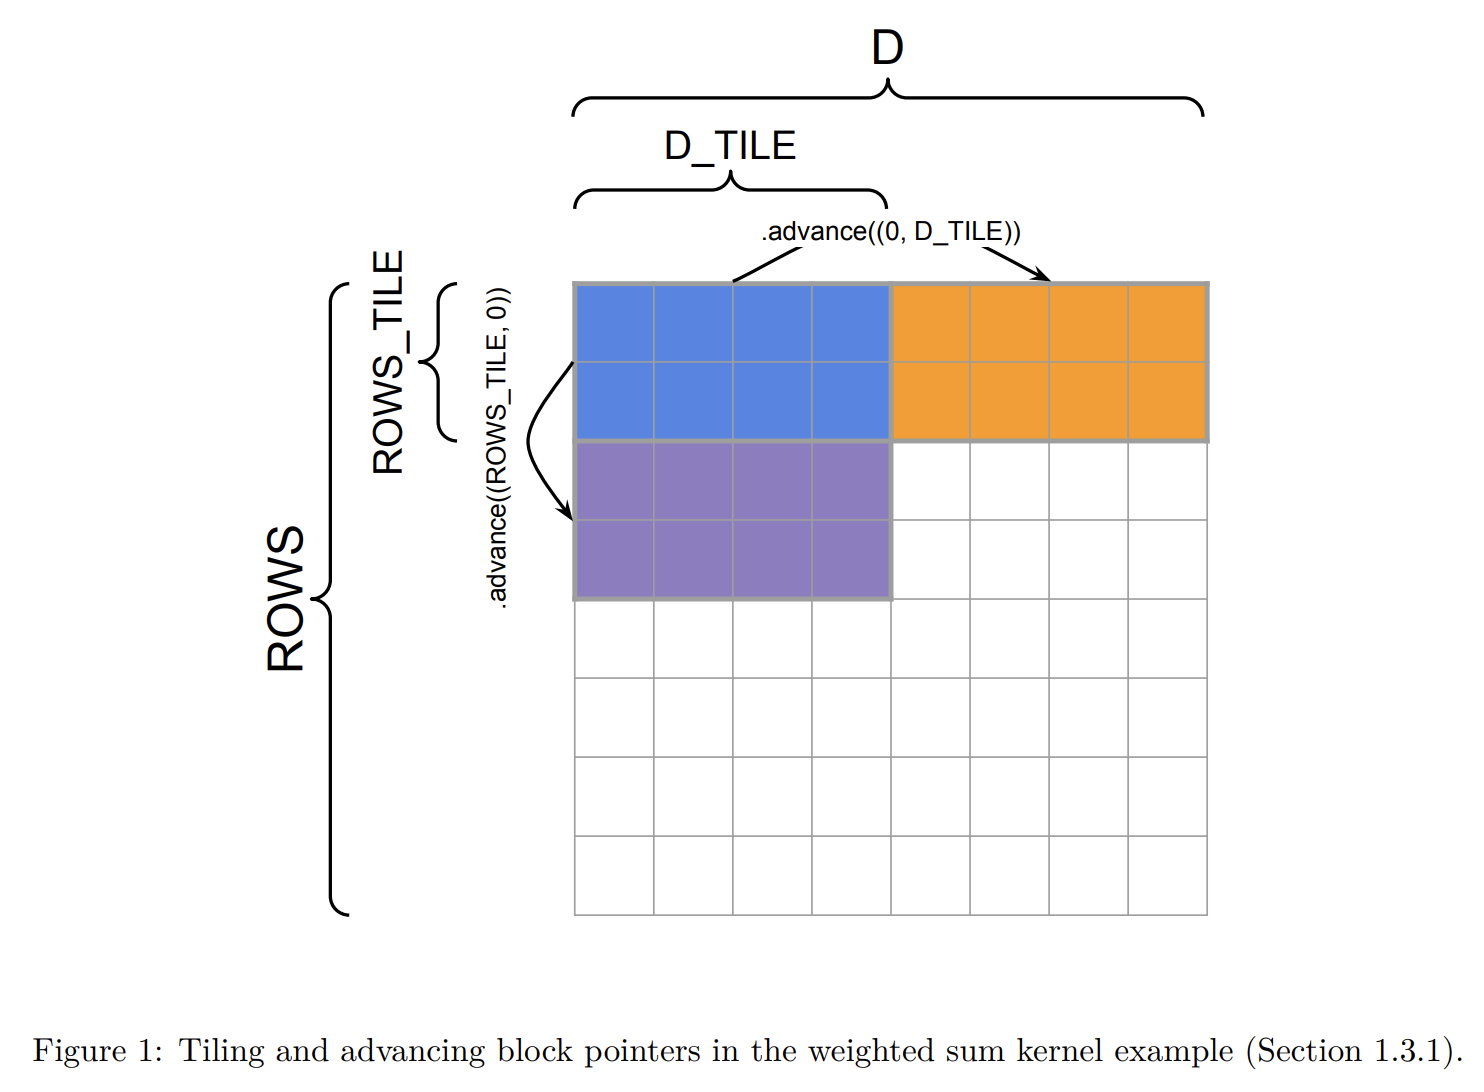
</center>

Refer to Figure 1 above for a schematic of tiling and how block pointers are advanced. The weighted sum function from above looks like the following:

```python
import triton
import triton.language as tl

@triton.jit
def weighted_sum_fwd(x_ptr, weight_ptr, output_ptr, x_stride_row, x_stride_dim, weight_stride_dim, output_stride_row,
                     ROWS, D, ROWS_TILE_SIZE: tl.constexpr, D_TILE_SIZE: tl.constexpr):
    # input pointers x_ptr, weight_ptr; output pointer output_ptr
    # Note: weight_stride_dim, output_stride_dim are usually 1
    # Each instance will compute the weighted sum of a tile of rows of x.
    # `tl.program_id` gives us a way to check which thread block we're running in
    row_tile_idx = tl.program_id(0)
    # Block pointers give us a way to select from an ND region of memory
    # and move our selection around.
    # The block pointer must know:
    # - The pointer to the first element of the tensor
    # - The overall shape of the tensor to handle out-of-bounds access
    # - The strides of each dimension to use the memory layout properly
    # - The ND coordinates of the starting block, i.e. "offsets"
    # - The block shape to use load/store at a time
    # - The order of the dimensions in memory from major to minor
    # axes (= np.argsort(strides)) for optimizations, especially useful on H100
    x_block_ptr = tl.make_block_ptr(
        x_ptr, shape=(ROWS, D,), 
        strides=(x_row_stride, x_stride_dim),   
        offsets=(row_tile_idx * ROWS_TILE_SIZE, 0), 
        block_shape=(ROWS_TILE_SIZE, D_TILE_SIZE), 
        order=(1, 0)
    )
    weight_block_ptr = tl.make_block_ptr(
        weight_ptr, 
        shape=(D,), 
        strides=(weight_stride_dim,), 
        offsets=(0,), 
        block_shape=(D_TILE_SIZE,),
        order=(0,)
    )
    output_block_ptr = tl.make_block_ptr(
        output_ptr, 
        shape=(ROWS,), 
        strides=(output_stride_row,), 
        offsets=(row_tile_idx * ROWS_TILE_SIZE,),
        block_shape=(ROWS_TILE_SIZE,), 
        order=(0,)
    )
    # Initialize a buffer to write to
    output = tl.zeros((ROWS_TILE_SIZE,), dtype=tl.float32)
    for i in range(tl.cdiv(D, D_TILE_SIZE)):
        # Load the current block pointer
        # Since ROWS_TILE_SIZE might not divide ROWS, and D_TILE_SIZE might not divide D,
        # we need boundary checks for both dimensions
        row = tl.load(x_block_ptr, boundary_check=(0, 1), padding_option='zero') # (ROWS_TILE_SIZE, D_TILE_SIZE)
        weight = tl.load(weight_block_ptr, boundary_check=(0,), padding_option='zero') # (D_TILE_SIZE,)
        # Compute the weighted sum of the row.
        output += tl.sum(row * weight[None, :], axis=1)
        # Move the pointers to the next tile.
        # These are (rows, columns) coordinate deltas
        x_block_ptr = x_block_ptr.advance((0, D_TILE_SIZE)) # Move by D_TILE_SIZE in the last dimension
        weight_block_ptr = weight_block_ptr.advance((D_TILE_SIZE,)) # Move by D_TILE_SIZE
    # Write output to the output block pointer (a single scalar per row).
    # Since ROWS_TILE_SIZE might not divide ROWS, we need boundary checks
    tl.store(output_block_ptr, output, boundary_check=(0,))
```

Let’s now wrap this kernel in a PyTorch Autograd function, that will interoperate with PyTorch (i.e. take `Tensors` as inputs, output a Tensor, and later also work with the autograd engine during the backward pass):

```python
class WeightedSumFunc(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, weight):
        # Cache x and weight to be used in the backward pass, when we
        # only receive the gradient wrt. the output tensor, and
        # need to compute the gradients wrt. x and weight.
        D, output_dims = x.shape[-1], x.shape[:-1]
        # Reshape input tensor to 2D
        input_shape = x.shape
        x = rearrange(x, '... d -> (...) d')
        ctx.save_for_backward(x, weight)
        assert len(weight.shape) == 1 and weight.shape[0] == D, 'Dimension mismatch'
        assert x.is_cuda and weight.is_cuda, 'Expected CUDA tensors'
        assert x.is_contiguous(), 'Our pointer arithmetic will assume contiguous x'
        ctx.D_TILE_SIZE = triton.next_power_of_2(D) // 16 # Roughly 16 loops through the embedding dimension
        ctx.ROWS_TILE_SIZE = 16 # Each thread processes 16 batch elements at a time
        ctx.input_shape = input_shape
        # Need to initialize empty result tensor. Note that these elements are not necessarily 0!
        y = torch.empty(output_dims, device=x.device)
        # Launch our kernel with n instances in our 1D grid.
        n_rows = y.numel()
        weighted_sum_fwd[(cdiv(n_rows, ctx.ROWS_TILE_SIZE),)](
            x, weight, y, x.stride(0), x.stride(1), weight.stride(0), y.stride(0),
            ROWS=n_rows, D=D, ROWS_TILE_SIZE=ctx.ROWS_TILE_SIZE, D_TILE_SIZE=ctx.D_TILE_SIZE
        )
        return y.view(input_shape[:-1])
```

Notice that when we invoke the Triton kernel with 

```python
weighted_sum_fwd[(cdiv(n_rows, ctx.ROWS_ ⌋ TILE_SIZE),)]
```

we define a so-called "launch grid" of thread blocks by passing the tuple `(cdiv(n_rows, ctx.ROWS_TILE_SIZE),)`. Then, we can access the thread block index with `tl.program_id(0)` in our kernel.

**Backward pass:** Since we are defining our own kernel, we will also need to write our own backward function.

In the forward pass, we were given the inputs to our layer, and needed to compute its outputs. In the backward pass, recall that we will be given the gradients of the objective with respect to our outputs, and need to compute the gradient with respect to each of our inputs. In our case, our operation has as inputs a matrix $x \in \mathbb{R}^{n \times h}$ and a weight vector $w \in \mathbb{R}^{h}$. For short, let’s call our operation $f(x,w)$, whose range is $\mathbb{R}^{n}$. Then, assuming we are given $\nabla_{f(x,w)} \mathcal{L}$, the gradient of loss $\mathcal{L}$ with respect to the output of our layer, we can apply the multivariate chain rule to obtain the following expressions for the gradients with respect to $x$ and $w$:

$$
(\nabla_x \mathcal{L})_{ij} = \sum_{k=1}^{n} \frac{\partial f(x,w)_k}{\partial x_{ij}} \, (\nabla_{f(x,w)} \mathcal{L})_k = w_j \cdot (\nabla_{f(x,w)} \mathcal{L})_i
$$

$$
(\nabla_w \mathcal{L})_{j} = \sum_{i=1}^{n} \frac{\partial f(x,w)_i}{\partial w_j} \, (\nabla_{f(x,w)} \mathcal{L})_i = \sum_{i=1}^{n} x_{ij} \cdot (\nabla_{f(x,w)} \mathcal{L})_i
$$

This gives a simple formula for computing the backward pass. To obtain the backward step with respect to $x$, we apply Eq 2 and take the outer product of $w$ and $\nabla_{f(x,w)} \mathcal{L}$. To compute the backward step with respect to $w$ (i.e. $(\nabla_w \mathcal{L})_j$), we must multiply our input gradient by the corresponding output row.

Our kernel for the backward pass will start by defining all the block pointers and then computing $\nabla_x \mathcal{L}$:

```python
@triton.jit
def weighted_sum_backward(x_ptr, weight_ptr, grad_output_ptr, grad_x_ptr, partial_grad_weight_ptr, stride_xr, 
                          stride_xd, stride_wd, stride_gr, stride_gxr, stride_gxd, stride_gwb, stride_gwd, NUM_ROWS, 
                          D, ROWS_TILE_SIZE: tl.constexpr, D_TILE_SIZE: tl.constexpr):
    # inputs x_ptr, weight_ptr; grad input weight_ptr ; grad outputs grad_x_ptr, partial_grad_weight_ptr
    row_tile_idx = tl.program_id(0)
    n_row_tiles = tl.num_programs(0)
    # Inputs
    grad_output_block_ptr = tl.make_block_ptr(
        grad_output_ptr,
        shape=(NUM_ROWS,), strides=(stride_gr,),
        offsets=(row_tile_idx * ROWS_TILE_SIZE,),
        block_shape=(ROWS_TILE_SIZE,),
        order=(0,),
    )
    x_block_ptr = tl.make_block_ptr(
        x_ptr,
        shape=(NUM_ROWS, D,), strides=(stride_xr, stride_xd),
        offsets=(row_tile_idx * ROWS_TILE_SIZE, 0),
        block_shape=(ROWS_TILE_SIZE, D_TILE_SIZE),
        order=(1, 0),
    )
    weight_block_ptr = tl.make_block_ptr(
        weight_ptr,
        shape=(D,), strides=(stride_wd,),
        offsets=(0,), block_shape=(D_TILE_SIZE,),
        order=(0,),
    )
    grad_x_block_ptr = tl.make_block_ptr(
        grad_x_ptr,
        shape=(NUM_ROWS, D,), strides=(stride_gxr, stride_gxd),
        offsets=(row_tile_idx * ROWS_TILE_SIZE, 0),
        block_shape=(ROWS_TILE_SIZE, D_TILE_SIZE),
        order=(1, 0),
    )
    partial_grad_weight_block_ptr = tl.make_block_ptr(
        partial_grad_weight_ptr,
        shape=(n_row_tiles, D,), strides=(stride_gwb, stride_gwd),
        offsets=(row_tile_idx, 0),
        block_shape=(1, D_TILE_SIZE),
        order=(1, 0),
    )
    for i in range(tl.cdiv(D, D_TILE_SIZE)):
        grad_output = tl.load(grad_output_block_ptr, boundary_check=(0,), padding_option='zero') # (ROWS_TILE_SIZE,)
        # Outer product for grad_x
        weight = tl.load(weight_block_ptr, boundary_check=(0,), padding_option='zero') # (D_TILE_SIZE,)
        grad_x_row = grad_output[:, None] * weight[None, :]
        tl.store(grad_x_block_ptr, grad_x_row, boundary_check=(0, 1))
        # Reduce as many rows as possible for the grad_weight result
        row = tl.load(x_block_ptr, boundary_check=(0, 1), padding_option='zero') # (ROWS_TILE_SIZE, D_TILE_SIZE)
        grad_weight_row = tl.sum(row * grad_output[:, None], axis=0, keep_dims=True)
        tl.store(partial_grad_weight_block_ptr, grad_weight_row, boundary_check=(1,)) # Never out of bounds for dim 0
        # Move the pointers to the next tile along D
        x_block_ptr = x_block_ptr.advance((0, D_TILE_SIZE))
        weight_block_ptr = weight_block_ptr.advance((D_TILE_SIZE,))
        partial_grad_weight_block_ptr = partial_grad_weight_block_ptr.advance((0, D_TILE_SIZE))
        grad_x_block_ptr = grad_x_block_ptr.advance((0, D_TILE_SIZE))
```

Computing the gradient $\nabla_x$ is simple, and we write the result to the appropriate tile of the output tensor. However, computing $\nabla_w$ is a bit more challenging. Each kernel instance is responsible for one row tile of $x$, but we now need to sum *across* rows of $x$. Instead of doing this sum directly in our backward pass, we will assume that `partial_grad_weight_ptr` contains an `n_row_tiles × H` matrix, where the first dimension is only reduced within a row tile from $x$. We reduce within the current row tile before writing to this tensor. Outside of the kernel, we reduce $\nabla_w$ using `torch.sum` to sum up the results from each row tile (or, we could write our own kernel for that). The final part of the `autograd.Function` is then relatively simple:

```python
class WeightedSumFunc(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, weight):
        # ... (defined earlier)
    @staticmethod
    def backward(ctx, grad_out):
        x, weight = ctx.saved_tensors
        ROWS_TILE_SIZE, D_TILE_SIZE = ctx.ROWS_TILE_SIZE, ctx.D_TILE_SIZE # These don't have to be the same
        n_rows, D = x.shape
        # Our strategy is for each thread block to first write to a partial buffer,
        # then we reduce over this buffer to get the final gradient.
        partial_grad_weight = torch.empty((cdiv(n_rows, ROWS_TILE_SIZE), D), device=x.device, dtype=x.dtype)
        grad_x = torch.empty_like(x)
        weighted_sum_backward[(cdiv(n_rows, ROWS_TILE_SIZE),)](
            x, weight,
            grad_out,
            grad_x, partial_grad_weight,
            x.stride(0), x.stride(1),
            weight.stride(0),
            grad_out.stride(0),
            grad_x.stride(0), grad_x.stride(1),
            partial_grad_weight.stride(0), partial_grad_weight.stride(1),
            NUM_ROWS=n_rows, D=D,
            ROWS_TILE_SIZE=ROWS_TILE_SIZE, D_TILE_SIZE=D_TILE_SIZE,
        )
        grad_weight = partial_grad_weight.sum(axis=0)
        return grad_x, grad_weight
```

Finally, we can now obtain a function that works much like those implemented in torch.nn.functional:

```python
f_weightedsum = WeightedSumFunc.apply
```

Now, calling `f_weightedsum` on two PyTorch tensors $x$ and $w$ will give a tensor such as the following:

```python
tensor([ 90.8563, -93.6815, -80.8884, ..., 103.4840, -21.4634, -24.0192],
device='cuda:0', grad_fn=<WeightedSumFuncBackward>)
```

Note the `grad_fn` attached to the tensor — this shows that PyTorch knows what to call in the backward pass when this tensor appears in the computation graph. This completes our Triton implementation of the weighted sum operation.

### FlashAttention-2 Forward Pass

You will replace your PyTorch attention implementation with a significantly improved Triton implementation following FlashAttention-2 (*Dao, 2023*). FlashAttention-2 employs some tricks to compute the forward pass in tiles, which allows for efficient memory access patterns and avoids the need to materialize the full attention matrix on global memory.

Before jumping into this section, we highly recommend reading atleast the original FlashAttention paper (*Dao et al., 2022*), which will give you intuition for the core technique that enables efficient attention with FlashAttention: computing the softmax in an online fashion across tiles, a technique proposed in (*Milakov and Gimelshein, 2018*). We also recommend checking out *He (2022)* for some more intuition on how GPUs actually execute PyTorch code.

**Understanding inefficiencies in vanilla attention:** Recall that the forward pass for attention (ignoring masking for now) can be written as:

$$
\begin{align*}
&\mathbf{S} = \mathbf{Q}\mathbf{K}^\top / \sqrt{d} \ , \\
&\mathbf{P}_{ij} = \mathrm{softmax}_j(\mathbf{S})_{ij} \ , \\
&\mathbf{O} = \mathbf{P}\mathbf{V} \ .
\end{align*}
$$

The standard backward pass is

$$
\begin{align*}
&\mathbf{dV} = \mathbf{P}^\top \mathbf{dO} \ , \\
&\mathbf{dP} = \mathbf{dO} \ \mathbf{V}^\top \ , \\
&\mathbf{dS}_i = \mathrm{dsoftmax}(\mathbf{dP}_i) = \left(\mathrm{diag}(\mathbf{P}_i) - \mathbf{P}_i \mathbf{P}_i^\top\right)\mathbf{dP}_i \ , \\
&\mathbf{dQ} = \mathbf{dS} \ \mathbf{K}/\sqrt{d} \ , \\
&\mathbf{dK} = \mathbf{dS}^\top \mathbf{Q}/\sqrt{d} \ .
\end{align*}
$$

As we can see, the backward pass depends on some very large activations from the forward pass. For example, computing $\mathbf{dV}$ requires $\mathbf{P}$, which are the attention scores of shape `(batch_size, n_heads, seq_len, seq_len)`—the size of this activation matrix depends *quadratically* on the sequence length, explaining the memory issues we encountered above when benchmarking attention at large sequence lengths. During both the forward and backward pass of vanilla attention, we pay significant memory IO costs to transfer $\mathbf{P}$ and other large activations between on-chip SRAM and GPU HBM. There are several such transfers made in standard implementations: for example, a standard backward pass implementation would read $\mathbf{P}$ from HBM in the computations above.

The main goal of FlashAttention is to avoid reading and writing the attention matrix to and from HBM, to reduce IO and peak memory costs. We accomplish this using three techniques: tiling, recomputation, and operator fusion.

**Tiling:** To avoid reading and writing the attention matrix to and from HBM, we compute the softmax reduction without access to the whole input. Specifically, we restructure the attention computation to split the input into tiles and make several passes over input tiles, thus incrementally performing the softmax reduction.

**Recomputation:** We avoid storing the large intermediate attention matrices of shape `(batch_size, n_heads, seq_len, seq_len)` in HBM. Instead, we will save certain "activation checkpoints" in HBM and then recompute part of the forward pass during the backward pass, to get the other activations we need for computing gradients. FlashAttention-2 also stores the `logsumexp` of the attention scores, $L$, which will be used to simplify the backward pass computation. The expression for $L$ is:

$$
L_i = \log\left(\sum_j \exp \mathbf{S}_{ij}\right) \ .
$$

In our final kernel we will compute this in an online manner, but the final result should be the same. With tiling and recomputation together, our memory IO and peak usage no longer depend on `sequence_length ** 2` and therefore we may use larger sequence lengths.

**Operator fusion:** Lastly, we avoid repeated memory IO for the attention matrix and other intermediate activations by performing all our operations in a single kernel—this is referred to as operator or kernel fusion. We will write a single Triton kernel for the forward pass that performs all the operations involved in attention with limited data transfer between HBM and SRAM. Operator fusion is partly enabled by recomputation, since we can avoid the usual memory IO we would pay to store every intermediate activation to HBM. For more intuition on these techniques, check out the FlashAttention papers (*Dao et al., 2022, Dao, 2023*).

**Backward pass with recomputation:** Using $L$, we can do the appropriate recomputation and compute the backward pass efficiently. Before we start the backward pass, we pre-compute into global memory the value $D = \mathrm{rowsum}(\mathbf{O} \circ \mathbf{dO})$ (where $\circ$ is element-wise multiplication), which is equal to $\mathrm{rowsum}(\mathbf{P} \circ \mathbf{dP})$ since $\mathbf{P}\mathbf{dP}^\top = \mathbf{P}(\mathbf{dO}\mathbf{V}^\top)^\top = (\mathbf{P}\mathbf{V})\mathbf{dO}^\top = \mathbf{O}\mathbf{dO}^\top$ (and $\mathrm{rowsum}(\mathbf{A} \circ \mathbf{B}) = \mathrm{diag}(\mathbf{A}\mathbf{B}^\top)$ for any matrices $\mathbf{A}$ and $\mathbf{B}$). With the $L$ and $D$ vectors, the backward pass can be computed without softmax. The full calculation for the backward pass is now:

$$
\begin{aligned}
\mathbf{S} &= \mathbf{Q}\mathbf{K}^\top/\sqrt{d} \ , \\
\mathbf{P}_{ij} &= \exp(\mathbf{S}_{ij} - L_i) \ , \\
\mathbf{dV} &= \mathbf{P}^\top \mathbf{dO} \ , \\
\mathbf{dP} &= \mathbf{dO} \ \mathbf{V}^\top \ , \\
\mathbf{dS}_{ij} &= \mathbf{P}_{ij} \circ (\mathbf{dP}_{ij} - D_i) \ , \\
\mathbf{dQ} &= \mathbf{dS} \ \mathbf{K}/\sqrt{d} \ , \\
\mathbf{dK} &= \mathbf{dS}^\top \mathbf{Q}/\sqrt{d} \ .
\end{aligned}
$$

We can see that the sequence of operations does not require us to have stored the attention scores $\mathbf{P}$ in HBM during the forward pass—we recompute them from the activations $\mathbf{Q}$, $\mathbf{K}$, and $L$ as shown above.

**Details of the flash attention forward pass:** Now that we have a high level idea of the techniques used in FlashAttention-2, we will dive into the details of the FA2 forward pass kernel that you will implement. In order to avoid reading and writing the attention matrix to and from HBM, we wish to use tiling, i.e. computing each tile of the output independently of the others. This requires us to be able to compute tiles of $\mathbf{P}$, ideally tiled in both dimensions (for queries and for keys).

However, when we apply softmax to $\mathbf{P}$, we require entire rows of $\mathbf{P}$ to be reduced to compute the softmax denominator, meaning we cannot compute $\mathbf{P}$ in tiles directly. FlashAttention-2 solves this problem using *online softmax*. In the following text, we will use subscript index i to denote the current query tile, and superscript index $j$ to denote the current key tile. The tiles along the query dimension will be of size $B_q$, and the key dimension, $B_k$. We will not tile along the hidden dimension $d$.

We also keep some row-wise running values, $m_i^{(j)} \in \mathbb{R}^{B_q}$ and $l_i^{(j)} \mathbb{R}^{B_q}$. The row-wise $m_i^{(j)}$ value is a running maximum, which is tracked so we can compute softmax in a numerically stable manner (recall this trick from our softmax implementation before). We will update $m_i^{(j)}$ with each new row-wise tile of $S$ (when $j$ increases). Using the running maximum, we can compute the unnormalized softmax values (numerators) as $\mathbf{\tilde P}_i^{(j)} = \exp(\mathbf{S}_{ij} − m_i^{(j)})$. Note $l_i^{(j)}$ is a running proxy for the softmax denominator, and will be updated using the unnormalized softmax values as $l_i^{(j)} = \exp(m_i^{(j-1)})$. When we finally write the output, we will need to finish normalizing it by using $l_i^{(T_k)}$, which is the final value of $l_i^{(j)}$ after processing all key tiles. *Algorithm 1* shows the forward pass as it should be implemented on GPU.

<center>
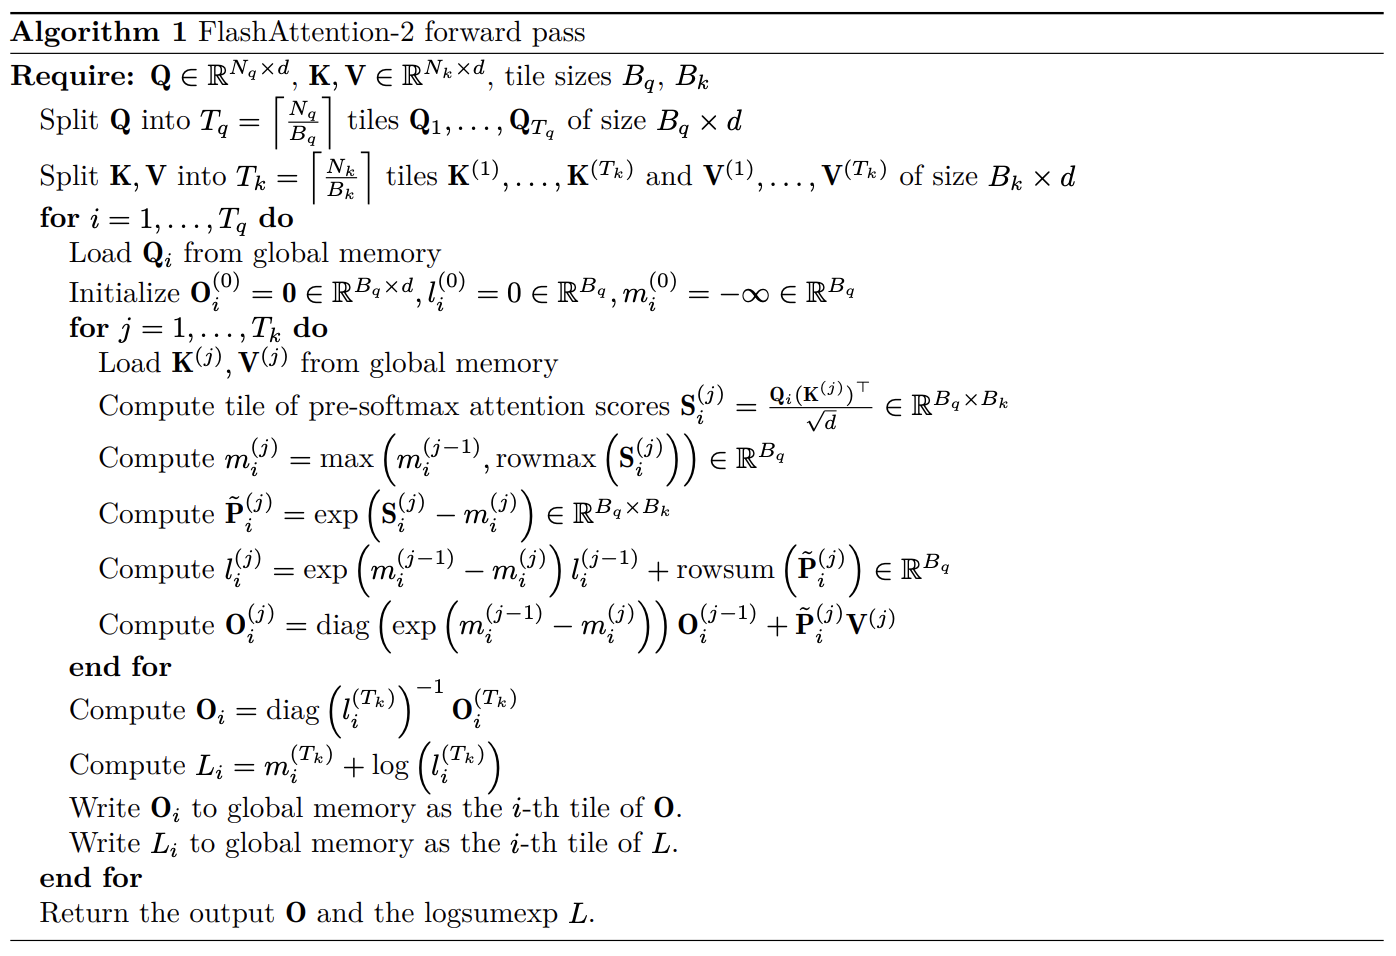
</center>

**Triton Tips and Tricks:** Before we get into implementing the forward pass in Triton, we collect here a few general tips and tricks for writing Triton kernels.
- You can use print statements in Triton with `tl.device_print` to debug per their [documentation](https://triton-lang.org/main/python-api/generated/triton.language.device_print.html). There is a setting `TRITON_INTERPRET=1` to run the Triton interpreter on CPU, though we have found it buggy.
- When defining block pointers, make sure they have the correct offsets, and that block offsets are multiplied by the appropriate tile sizes.
- The launch grid of thread blocks is set with `kernel_fn[(launch_grid_d1, launch_grid_d2, ...)](...arguments...)` in the methods of the `torch.autograd.Function` subclass, as we saw in the weighted sum example.
- Perform matrix multiplications with `tl.dot`.
- To advance a block pointer, use `*_block_ptr = *_block_ptr.advance(...)`.

#### Problem: Flash Forward

Use the `FlashAttentionAutograd` class below to implement the FlashAttention-2 forward pass in pure PyTorch (i.e. no Triton). This class subclasses `autograd.Function`. Note this will be a lot slower than the native PyTorch implementation of FlashAttention-2, but it will help you debug your Triton kernel.

The forward pass here takes as input $Q$, $K$, and $V$, as well as a flag `is_causal`, and produces the output $O$ and the `logsumexp` value $L$. You can ignore the `is_causal` flag for now. This function should then save $L$, $Q$, $K$, $V$, $O$ for the backward pass and return $O$. If you need something to compare against, you can implement the equations above in PyTorch and compare your outputs.

*Note:* The forward method of `autograd.Function` should always take in the context `ctx` as its first parameter. Moreover, any `autograd.Function` class must also implement a backward method. 

For the forward method, you'll want to determine your own tile sizes, making sure they are at least of size `16 × 16`. For now we'll just raise `NotImplementedError` for the backward method.

We'll use the adapter `get_flashattention_autograd_function_pytorch` to test your implementation. Note that we'll always test with dimensions that are at least 16, and always a power of 2. This way you won't need to worry about out-of-bounds access issues.

In [ ]:
class FlashAttentionAutograd(torch.autograd.Function):
    def __init__(self):
        """
        Constructor for a torch.autograd.Function subclass implementation of FlashAttention2.
        """
        super().__init__()
        raise NotImplementedError

    def forward(ctx, Q, K, V, is_causal=False):
        """
        Forward pass for FlashAttention2.
        Args:
            ctx.
            Q.
            K.
            V.
            is_causal: bool = False.
        Returns:
            O.
        """
        def _backward():
            raise NotImplementedError
        raise NotImplementedError

In [ ]:
def get_flashattention_autograd_function_pytorch():
    """
    Adapter function for the main FlashAttentionAutograd class.
    """
    return FlashAttentionAutograd

test_flash_forward_pass_pytorch(get_flashattention_autograd_function_pytorch)

Second, write a Triton kernel for the forward pass of FlashAttention-2 following *Algorithm 1*. Then, write another subclass of `torch.autograd.Function` that calls this (fused) kernel in the forward pass, instead of computing the result in PyTorch.

A few problem-specific tips:
- To debug, we suggest comparing the results of each Triton operation you perform with the tiled PyTorch implementation you wrote in part one.
- Your launch grid should be set as ($T_q$, `batch_size`), meaning each Triton program instance will load only elements from a single batch index, and only read/write to a single query tile of $Q$, $O$, and $L$.
- The kernel should only have a single loop, which will iterate key tiles $1 \leq j \leq T_k$.
- Advance block pointers at the end of the loop.
- Use the function declaration below (using the block pointer we give you, you should be able to infer the setup of the rest of the pointers):

```python
@triton.jit
def flash_fwd_kernel(Q_ptr, K_ptr, V_ptr, O_ptr, L_ptr, stride_qb, stride_qq, stride_qd, stride_kb, stride_kk, stride_kd,
                     stride_vb, stride_vk, stride_vd, stride_ob, stride_oq, stride_od, stride_lb, stride_lq,
                     N_QUERIES, N_KEYS, scale, D: tl.constexpr, Q_TILE_SIZE: tl.constexpr, K_TILE_SIZE: tl.constexpr):
    # Program indices
    query_tile_index = tl.program_id(0)
    batch_index = tl.program_id(1)
    # Offset each pointer with the corresponding batch index
    # multiplied with the batch stride for each tensor
    Q_block_ptr = tl.make_block_ptr(
        Q_ptr + batch_index * stride_qb,
        shape=(N_QUERIES, D),
        strides=(stride_qq, stride_qd),
        offsets=(query_tile_index * Q_TILE_SIZE, 0),
        block_shape=(Q_TILE_SIZE, D),
        order=(1, 0),
    )
    ...
```

where scale is $1/\sqrt{d}$ and `Q_TILE_SIZE` and `K_TILE_SIZE` are $B_q$ and $B_k$ respectively. You can tune these later.

These additional guidelines may help you avoid precision issues:
- The on chip buffers $(O_i, l, m)$ should have dtype `tl.float32`. If you’re accumulating into an output buffer, use the `acc` argument `acc = tl.dot(..., acc=acc)`.
- Cast $\tilde P_i^{(j)}$ to the `dtype` of $V^{(j)}$ before multiplying them, and cast $O_i$ to the appropriate `dtype` before writing it to global memory. Casting is done with `tensor.to`. You can get the `dtype` of a tensor with `tensor.dtype`, and the `dtype` of a block pointer/pointer with `*_block_ptr.type.element_ty`.

Write a `torch.autograd.Function` subclass that implements FlashAttention-2 in the forward pass using your Triton kernel. Implement
the adapter `get_flash_autograd_function_triton`. Then, make sure it passes the test below.

In [ ]:
# to fill in

In [ ]:
def get_flashattention_autograd_function_triton():
    """
    Returns a torch.autograd.Function subclass that implements FlashAttention2 using Triton kernels.
    This class should implement the same operations as the class returned in get_flashattention_autograd_function_pytorch(),
    but it should do so by invoking custom Triton kernels in the forward and backward passes.
    Returns:
        A class object (not an instance of the class)
    """
    # For example: return MyTritonFlashAttentionAutogradFunctionClass
    raise NotImplementedError

test_flash_forward_pass_triton(get_flashattention_autograd_function_triton)

Finally, add a flag as the last argument to your autograd.Function implementation for causal masking. This should be a boolean flag that when set to True enables an index comparison for causal masking. Your Triton kernel should have a corresponding additional parameter `is_causal: tl.constexpr` (this is a required type annotation). In Triton, construct appropriate index vectors for queries and keys, and compare them to form a square mask of size $B_q \times B_k$. For elements that are masked out, add the constant value of `-1e6` to the corresponding elements of the attention score matrix $S_i^{(j)}$. Make sure to save the mask flag for backward using `ctx.is_causal = is_causal`.

Provide an additional flag for your `torch.autograd.Function` subclass that implements the FlashAttention-2 forward pass with causal masking using your Triton kernel. Make sure that the flag is optional with default False so the previous tests still pass.

In [ ]:
# implementation code

**Implementing the backward pass with recomputation:** Notice that unlike the standard backward pass described above, we can use recomputation to avoid the softmax operation in the backward pass. This means that we can compute the backward pass using a trivial kernel, and no online tricks are required. Thus, for this part, you can implement backward by calling `torch.compile` on a regular PyTorch function (not Triton).

#### Problem: Flash Backward

Implement the backward pass for your FlashAttention-2 `autograd.Function` using PyTorch (not Triton) and `torch.compile`. Your implementation should take the $Q$, $K$, $V$, $O$, $dO$, and $L$ tensors as output, and return $dQ$, $dK$, and $dV$. Remember to compute and use the $D$ vector. You may follow along the computations described above. To test your implementation, run the test below.

In [ ]:
# implementation code

In [ ]:
# test_flash_backward_pytorch(get_flashattention_autograd_function_pytorch) # figure out what to do with this...

#### Problem: Flash Backward

Let’s now compare the performance of your (partially) Triton implementation of FlashAttention-2 with your PyTorch implementation of regular Attention.

Write a benchmarking script using `triton.testing.do_bench` that compares the performance of your (partially) Triton implementation of FlashAttention-2 forward and backward passes with a regular PyTorch implementation (i.e. not using FlashAttention).

Specifically, you will report a table that includes latencies for forward, backward, and the endto-end forward-backward pass, for both your Triton and PyTorch implementations. Randomly generate any necessary inputs before you start benchmarking, and run the benchmark on a single H100. Always use batch size 1 and causal masking. Sweep over the cartesian product of sequence lengths of various powers of two from `128` up to `65536`, embedding dimension sizes of various powers of two from `16` up to size `128`, and precisions of `torch.bfloat16` and `torch.float32`. You will likely need to adjust tile sizes depending on the input sizes.

Provide a table of results comparing your implementation of FlashAttention-2 with the PyTorch implementation, using the settings above and reporting forward, backward, and end-to-end latencies.

In [ ]:
# implementation code

#### Problem: Triton backward pass

To get more practice with Triton and improving your timings, we'll also provide below the tiled FlashAttention-2 backward pass, which you can implement in Triton. *Algorithm 2* shows the FlashAttention-2 backward pass as it should be implemented in Triton. A key trick here is to compute $P$ twice, once for the backward pass for $dQ$ and another time for $dK$ and $dV$. This lets us skip synchronization across thread blocks.

<center>
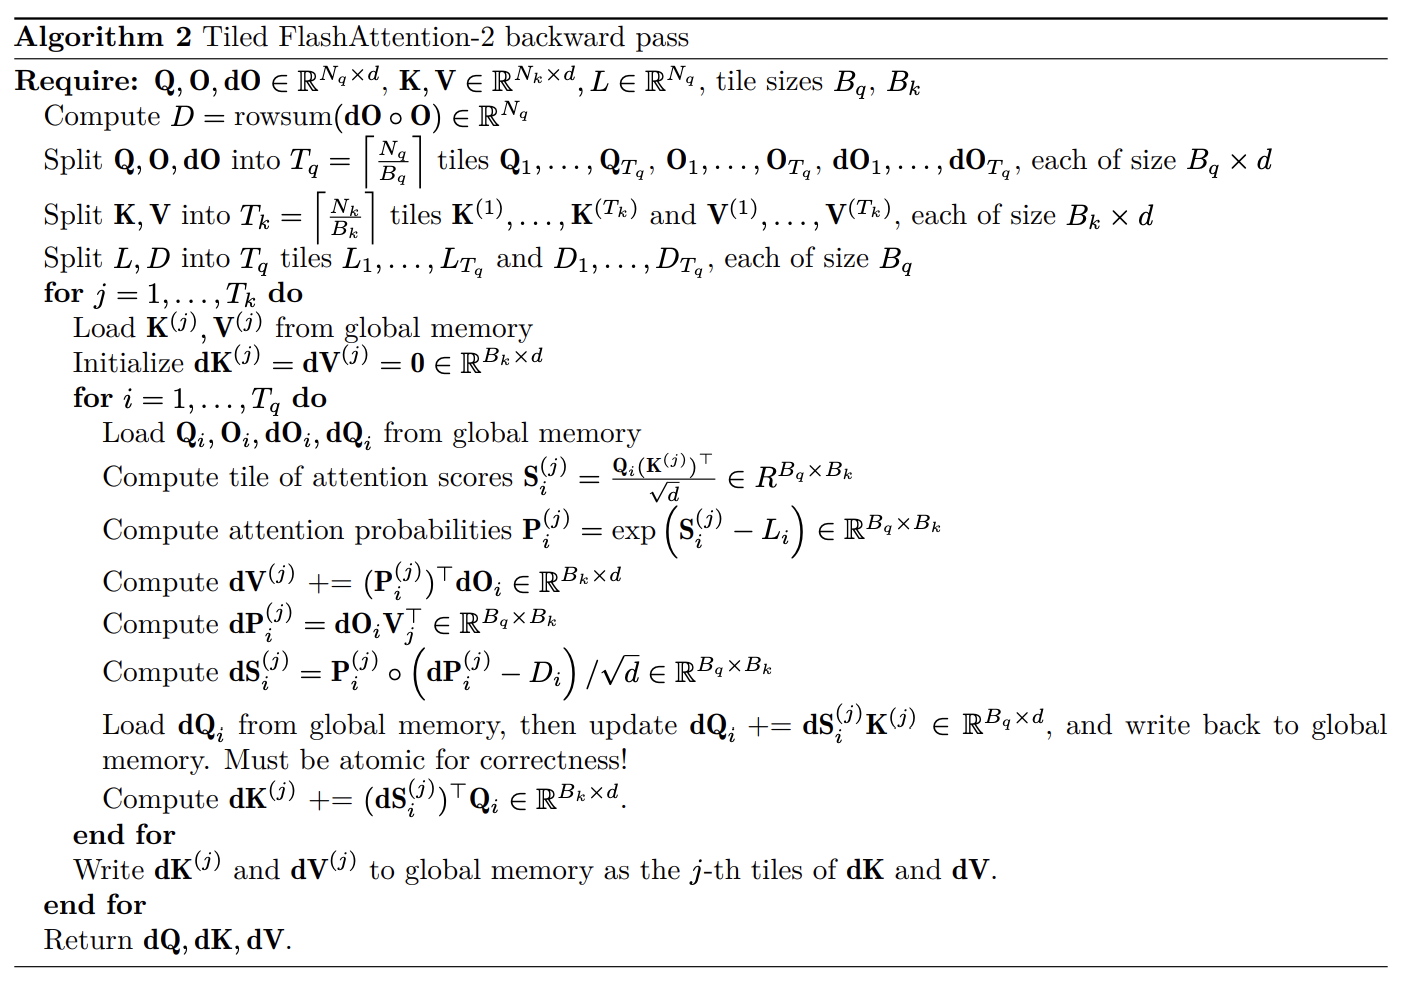
</center>

In [ ]:
# implementation code

In [ ]:
# test_flash_backward_triton(get_flashattention_autograd_function_triton) # figure out what to do with this...